# Statistical Rethinking - Chapter X

Work through problems from the book below.

## Setup

Run this cell first to import required libraries.

In [3]:
import os
import arviz as az
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random

import numpyro  
import numpyro.distributions as dist
import numpyro.optim as optim
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoLaplaceApproximation
from typing import List

az.style.use("arviz-darkgrid")
numpyro.set_platform("cpu")

print("✓ Environment ready!")
print(f"NumPyro version: {numpyro.__version__}")

✓ Environment ready!
NumPyro version: 0.21.0


## Work Area

Add cells below for your solutions. Use:
- `B` key (in command mode) to insert cell below
- `M` key to convert cell to markdown (for notes/explanations)
- `Y` key to convert cell to code
- `Shift+Enter` to run cell and move to next

## 2M1

Recall the globe tossing model from the chapter. Compute and plot the grid approximate posterior distribution for each of the following sets of observations. In each case, assume a uniform prior for p:
1. W, W, W 
2. W, W, W, L
3. L, W, W, L, W, W, W


In [39]:
observation_1 = ['W', 'W', 'W']
observation_2 = ['W', 'W', 'W','L']
observation_3 = ['L','W', 'W', 'L','W', 'W','W']
num_elements = 20

In [40]:
def graph_2M1(observation: List[str], num_elements: int):
    p_grid = jnp.linspace(start = 0, stop=1, num=num_elements)
    prior = jnp.repeat(1,num_elements)
    num_events = len(observation)
    num_positives = len([el for el in observation if el == 'W'])

    binominal_dist = dist.Binomial(total_count=num_events, probs = p_grid)
    log_prob = binominal_dist.log_prob(num_positives)
    likelihood = jnp.exp(log_prob)

    # product of likelihood and prior
    posterior = likelihood * prior
    # standardize to sum to 1
    posterior = posterior / posterior.sum()

    plt.plot(p_grid, posterior, "-o")
    plt.xlabel('probability of water')
    plt.ylabel = ('posterior probability')
    plt.title(f"Number of considered points {num_elements} - {','.join(observation)}")
    plt.show()

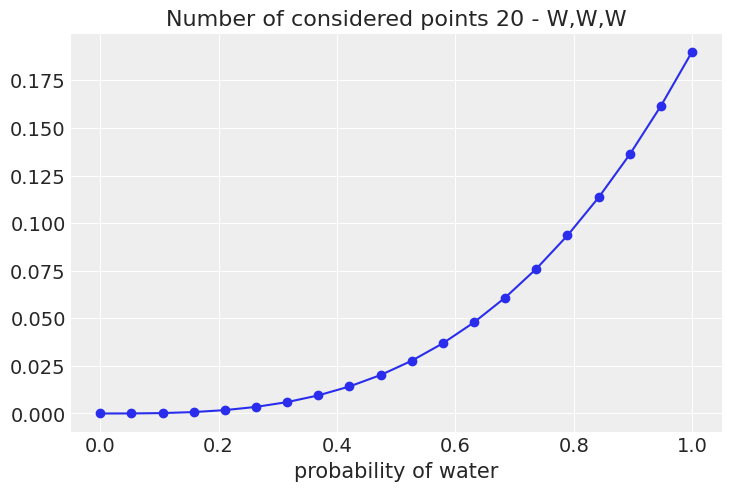

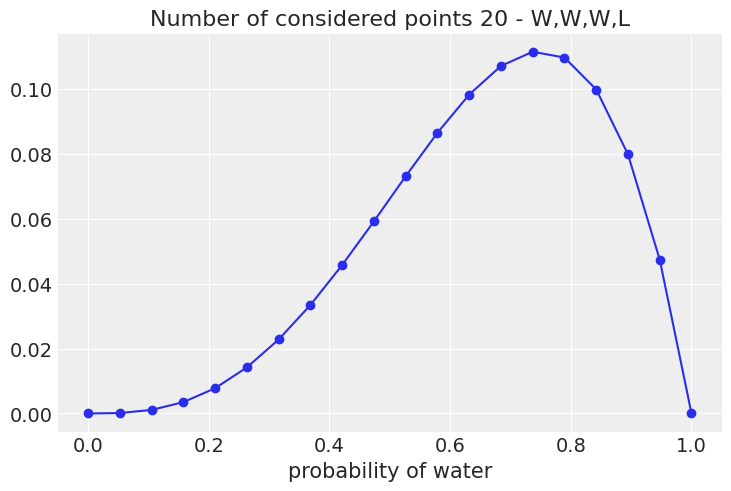

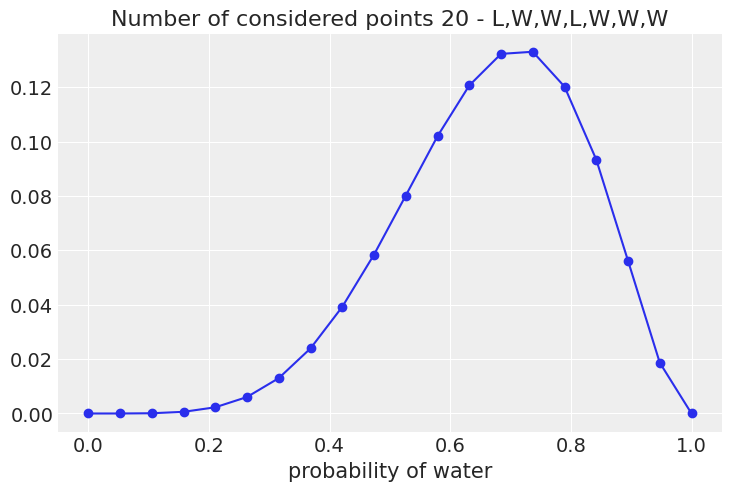

In [41]:
graph_2M1(observation_1, 20)
graph_2M1(observation_2, 20)
graph_2M1(observation_3, 20)

## 2M2

Now assume a prior for p that is equal to zero when p < 0.5 and is a positive constant when
p ≥ 0.5. Again compute and plot the grid approximate posterior distribution for each of the sets of
observations in the problem just above.

In [31]:
def graph_2M2(observation: List[str], num_elements: int):
    p_grid = jnp.linspace(start = 0, stop=1, num=num_elements)
    prior = jnp.where(p_grid<0.5, 0 , 1)
    num_events = len(observation)
    num_positives = len([el for el in observation if el == 'W'])

    binominal_dist = dist.Binomial(total_count=num_events, probs = p_grid)
    log_prob = binominal_dist.log_prob(num_positives)
    likelihood = jnp.exp(log_prob)

    # product of likelihood and prior
    posterior = likelihood * prior
    # standardize to sum to 1
    posterior = posterior / posterior.sum()

    plt.plot(p_grid, posterior, "-o")
    plt.xlabel('probability of water')
    plt.ylabel = ('posterior probability')
    plt.title(f"Number of considered points {num_elements} - {','.join(observation)}")
    plt.show()

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


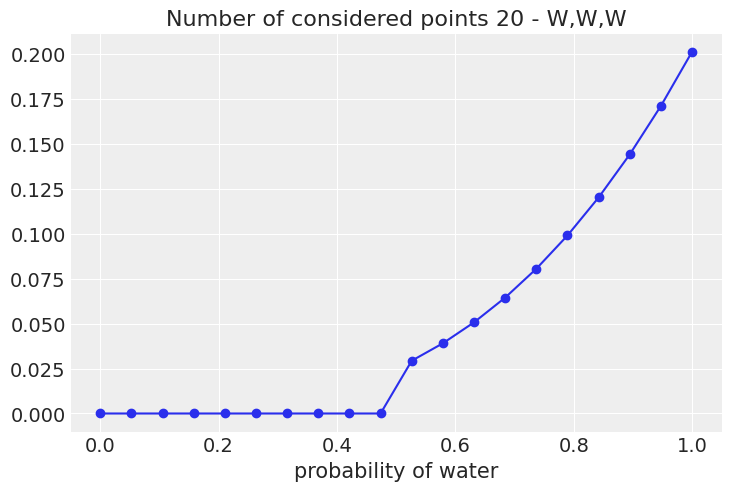

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


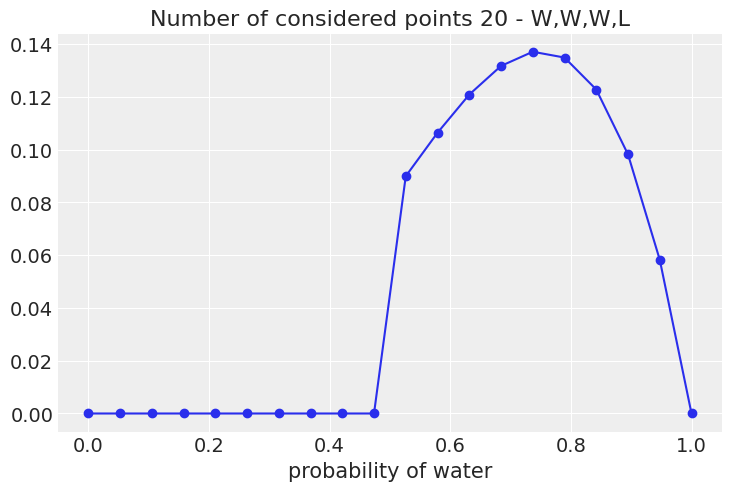

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


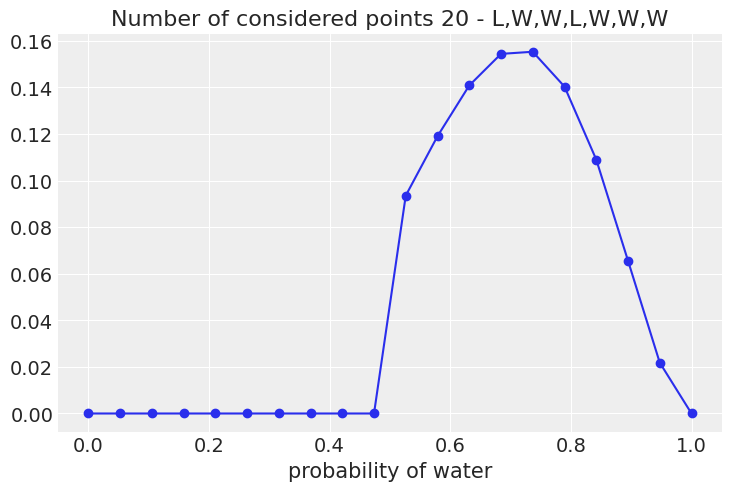

In [43]:
graph_2M2(observation_1, 20)
graph_2M2(observation_2, 20)
graph_2M2(observation_3, 20)

## 2M3

Suppose there are two globes, one for Earth and one for Mars. The Earth globe is 70% covered
in water. The Mars globe is 100% land. Further suppose that one of these globes—you don’t know
which—was tossed in the air and produced a “land” observation. Assume that each globe was equally
likely to be tossed. Show that the posterior probability that the globe was the Earth, conditional on
seeing “land” (Pr(Earth|land)), is 0.23.

In [47]:
p_land_earth = 0.3
p_land_mars = 1.0
p_earth_thrown = 0.5

# probability of land
p_land = (p_earth_thrown * p_land_earth) + ((1 - p_earth_thrown) * p_land_mars)

# probability of Earth, given land (using Bayes' Theorem)
p_earth_given_land = (p_land_earth * p_earth_thrown) / p_land

p_earth_given_land

0.23076923076923075

## 2H1

Suppose there are two species of panda bear. Both are equally common in the wild and live
in the same places. They look exactly alike and eat the same food, and there is yet no genetic assay
capable of telling them apart. They differ however in their family sizes. Species A gives birth to twins
10% of the time, otherwise birthing a single infant. Species B births twins 20% of the time, otherwise
birthing singleton infants. Assume these numbers are known with certainty, from many years of field
research.

Now suppose you are managing a captive panda breeding program. You have a new female panda
of unknown species, and she has just given birth to twins. What is the probability that her next birth
will also be twins?

In [63]:
p_species_a_twins = 0.1
p_species_b_twins = 0.2

# Posterior probability calculation
likelihood = np.array([p_species_a_twins, p_species_b_twins])
# Prior is 1 for either species because we observed a twin being born
prior = np.array([1, 1])
posterior = likelihood * prior
# 
posterior = posterior / np.sum(posterior)

# The probability the next birth is twins is the probability the panda belongs
# to each species times the likelihood each species gives birth to twins
p_twinagin = (posterior[0] * p_species_a_twins) + (posterior[1] * p_species_b_twins)

print(p_twinagin)

0.16666666666666666
